# Part 2 - English to French Translation with Seq2Seq LSTM

Neural machine translation using an encoder-decoder LSTM with teacher forcing.


## Dataset Download and Execution Instructions

Run this notebook from top to bottom in a Python environment with TensorFlow installed.

Datasets are downloaded automatically:

- *Frankenstein* is downloaded from Project Gutenberg through `tf.keras.utils.get_file`.
- The English-French dataset is downloaded from the ManyThings/Tatoeba Anki collection and limited to 10,000 sentence pairs.
- AG News is downloaded through `tensorflow_datasets`.

Recommended execution environment:

- Python 3.10 or newer.
- TensorFlow 2.15 or newer.
- A GPU is recommended for the full training configuration.

The first LSTM text generation model is intentionally trained for 32 epochs as required. On CPU this can take a long time.

In [14]:
# Global imports and reproducibility setup
import os
import re
import random
import string
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


## Shared Helper Functions

These utility functions keep plotting, text cleaning, and prediction display consistent across the three parts.

In [15]:
def plot_training_curves(history, metrics=("loss", "accuracy"), title_prefix="Model"):
    'Plot training and validation curves from a Keras History object.'
    history_df = pd.DataFrame(history.history)
    available_metrics = [m for m in metrics if m in history_df.columns]
    if not available_metrics:
        available_metrics = ["loss"]

    fig, axes = plt.subplots(1, len(available_metrics), figsize=(6 * len(available_metrics), 4))
    if len(available_metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, available_metrics):
        ax.plot(history_df[metric], label=f"train_{metric}")
        val_metric = f"val_{metric}"
        if val_metric in history_df:
            ax.plot(history_df[val_metric], label=val_metric)
        ax.set_title(f"{title_prefix}: {metric}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.legend()

    plt.tight_layout()
    plt.show()


def normalize_spaces(text):
    'Lowercase text and collapse repeated whitespace.'
    return re.sub(r"\s+", " ", text.lower()).strip()


def clean_sentence(text):
    'Basic sentence cleaning used for translation and classification examples.'
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z\u00C0-\u00FF?.!,;:'\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Part 2 - English to French Translation with Seq2Seq LSTM

## Objective

This part builds a neural machine translation model with an encoder-decoder LSTM architecture. The encoder reads an English sentence and compresses it into recurrent state vectors. The decoder uses teacher forcing during training to predict the French sentence one token at a time.

## 2.1 Data Loading and Cleaning

The ManyThings English-French sentence-pair dataset is downloaded and limited to a maximum of 10,000 pairs as required. Missing rows are removed. Text is lowercased and lightly cleaned.

In [16]:
FRA_ENG_URL = "https://www.manythings.org/anki/fra-eng.zip"
fra_zip_path = "fra-eng.zip"

with zipfile.ZipFile(fra_zip_path, "r") as zf:
    zf.extractall(Path(fra_zip_path).parent / "fra-eng")

fra_txt_path = Path(fra_zip_path).parent / "fra-eng" / "fra.txt"
raw_pairs = pd.read_csv(
    fra_txt_path,
    sep="\t",
    header=None,
    names=["english", "french", "metadata"],
    usecols=[0, 1, 2],
)

pairs = raw_pairs[["english", "french"]].dropna().head(10_000).copy()
pairs["english"] = pairs["english"].map(clean_sentence)
pairs["french"] = pairs["french"].map(clean_sentence)
pairs = pairs[(pairs["english"].str.len() > 0) & (pairs["french"].str.len() > 0)].reset_index(drop=True)

pairs["french_in"] = "<start> " + pairs["french"]
pairs["french_out"] = pairs["french"] + " <end>"

print("Sentence pairs:", len(pairs))
pairs.head()

Sentence pairs: 10000


,english,french,french_in,french_out
0,go.,va !,<start> va !,va ! <end>
1,go.,marche.,<start> marche.,marche. <end>
2,go.,en route !,<start> en route !,en route ! <end>
3,go.,bouge !,<start> bouge !,bouge ! <end>
4,hi.,salut !,<start> salut !,salut ! <end>


## 2.2 Tokenization and Vocabulary Creation

Separate tokenizers are used for English and French. French decoder sequences include `<start>` and `<end>` tokens, which mark the beginning and end of generated translations.

In [17]:
MAX_PAIRS = 10_000
MAX_NUM_WORDS = 12_000

eng_tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=MAX_NUM_WORDS,
    filters="",
    lower=False,
    oov_token="<unk>",
)
fra_tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=MAX_NUM_WORDS,
    filters="",
    lower=False,
    oov_token="<unk>",
)

eng_tokenizer.fit_on_texts(pairs["english"])
fra_tokenizer.fit_on_texts(pd.concat([pairs["french_in"], pairs["french_out"]]))

eng_vocab_size = min(MAX_NUM_WORDS, len(eng_tokenizer.word_index) + 1)
fra_vocab_size = min(MAX_NUM_WORDS, len(fra_tokenizer.word_index) + 1)

print("English vocabulary size:", eng_vocab_size)
print("French vocabulary size:", fra_vocab_size)
print("French special token ids:", {
    "<start>": fra_tokenizer.word_index.get("<start>"),
    "<end>": fra_tokenizer.word_index.get("<end>"),
})

English vocabulary size: 2711
French vocabulary size: 5334
French special token ids: {'<start>': 2, '<end>': 3}


## 2.3 Sequence Preparation with Teacher Forcing

Teacher forcing feeds the correct previous French token into the decoder during training. Therefore:

- Encoder input: English sentence.
- Decoder input: French sentence starting with `<start>`.
- Decoder target: French sentence ending with `<end>`.

All sequences are padded to fixed lengths.

In [18]:
encoder_sequences = eng_tokenizer.texts_to_sequences(pairs["english"])
decoder_input_sequences = fra_tokenizer.texts_to_sequences(pairs["french_in"])
decoder_target_sequences = fra_tokenizer.texts_to_sequences(pairs["french_out"])

max_encoder_len = max(len(seq) for seq in encoder_sequences)
max_decoder_len = max(len(seq) for seq in decoder_input_sequences)

encoder_input_data = keras.preprocessing.sequence.pad_sequences(
    encoder_sequences,
    maxlen=max_encoder_len,
    padding="post",
)
decoder_input_data = keras.preprocessing.sequence.pad_sequences(
    decoder_input_sequences,
    maxlen=max_decoder_len,
    padding="post",
)
decoder_target_data = keras.preprocessing.sequence.pad_sequences(
    decoder_target_sequences,
    maxlen=max_decoder_len,
    padding="post",
)
decoder_target_data = np.expand_dims(decoder_target_data, axis=-1)

split_idx = int(len(encoder_input_data) * 0.9)

train_inputs = [encoder_input_data[:split_idx], decoder_input_data[:split_idx]]
val_inputs = [encoder_input_data[split_idx:], decoder_input_data[split_idx:]]
y_train_trans = decoder_target_data[:split_idx]
y_val_trans = decoder_target_data[split_idx:]

print("Encoder input shape:", encoder_input_data.shape)
print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

Encoder input shape: (10000, 4)
Decoder input shape: (10000, 11)
Decoder target shape: (10000, 11, 1)


## 2.4 Seq2Seq Model Architecture

The encoder consists of an embedding layer followed by an LSTM that returns the final hidden and cell states. The decoder has its own embedding layer and LSTM. The decoder LSTM is initialized with the encoder states, then a dense softmax layer predicts the next French token at each time step.

In [19]:
EMBEDDING_DIM = 128
LSTM_UNITS = 256
BATCH_SIZE_TRANS = 64
EPOCHS_TRANS = 20

encoder_inputs = keras.Input(shape=(None,), name="encoder_inputs")
encoder_embedding = layers.Embedding(
    eng_vocab_size,
    EMBEDDING_DIM,
    mask_zero=True,
    name="encoder_embedding",
)(encoder_inputs)
_, state_h, state_c = layers.LSTM(
    LSTM_UNITS,
    return_state=True,
    name="encoder_lstm",
)(encoder_embedding)
encoder_states = [state_h, state_c]

decoder_inputs = keras.Input(shape=(None,), name="decoder_inputs")
decoder_embedding_layer = layers.Embedding(
    fra_vocab_size,
    EMBEDDING_DIM,
    mask_zero=True,
    name="decoder_embedding",
)
decoder_embedding = decoder_embedding_layer(decoder_inputs)
decoder_lstm = layers.LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm",
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_dense = layers.Dense(fra_vocab_size, activation="softmax", name="decoder_softmax")
decoder_outputs = decoder_dense(decoder_outputs)

translation_model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="eng_fra_seq2seq_lstm")

translation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

translation_model.summary()

Model: "eng_fra_seq2seq_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_inputs (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_embedding (Embedding) │ (None, None, 128)         │         347,008 │ encoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None)              │               0 │ encoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_embedding (Embedding) │ (None, None, 128)         │         682,752 │ decoder_inputs[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_lstm (LSTM)           │ [(None, 256), (None,      │         394,240 │ encoder_embedding[0][0],   │
│                               │ 256), (None, 256)]        │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_lstm (LSTM)           │ [(None, None, 256),       │         394,240 │ decoder_embedding[0][0],   │
│                               │ (None, 256), (None, 256)] │                 │ encoder_lstm[0][1],        │
│                               │                           │                 │ encoder_lstm[0][2]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_softmax (Dense)       │ (None, None, 5334)        │       1,370,838 │ decoder_lstm[0][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,189,078 (12.17 MB)

 Trainable params: 3,189,078 (12.17 MB)

 Non-trainable params: 0 (0.00 B)

## 2.5 Training

The model is optimized with Adam and sparse categorical cross-entropy. Sparse targets avoid building a very large one-hot target tensor.

In [20]:
translation_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_eng_fra_seq2seq_lstm.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
]

translation_history = translation_model.fit(
    train_inputs,
    y_train_trans,
    validation_data=(val_inputs, y_val_trans),
    batch_size=BATCH_SIZE_TRANS,
    epochs=EPOCHS_TRANS,
    callbacks=translation_callbacks,
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.2774 - loss: 5.5971 - val_accuracy: 0.2272 - val_loss: 5.2422
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.3247 - loss: 4.2928 - val_accuracy: 0.3204 - val_loss: 4.9439
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - accuracy: 0.3971 - loss: 3.8342 - val_accuracy: 0.3522 - val_loss: 4.7464
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.4506 - loss: 3.4553 - val_accuracy: 0.3721 - val_loss: 4.6038
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.4786 - loss: 3.1586 - val_accuracy: 0.3943 - val_loss: 4.5197
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.5013 - loss: 2.9001 - val_accuracy: 0.4084 - val_loss: 4.4658
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.5242 - loss: 2.6670 - val_accuracy: 0.4213 - val_loss: 4.4172
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 126ms/step - accuracy: 0.5430 - loss: 2

## 2.6 Training Visualization

Loss and accuracy curves help diagnose underfitting, overfitting, and convergence behavior.

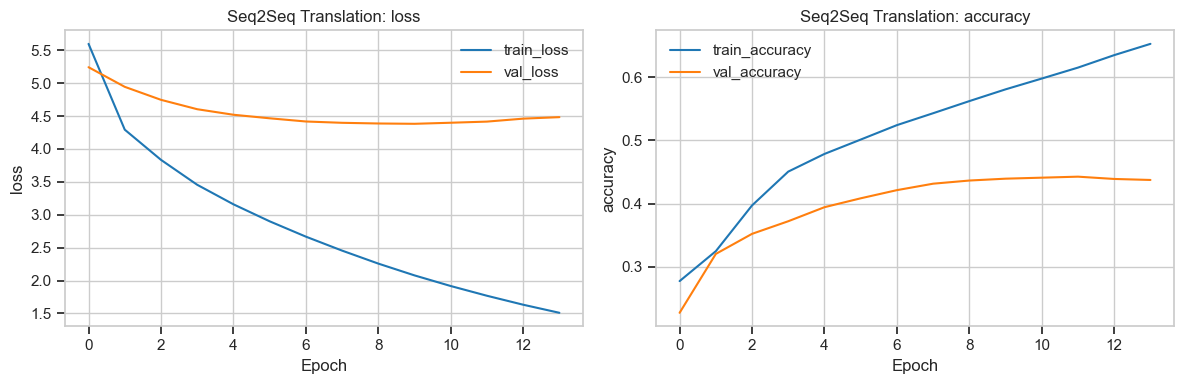

In [21]:
plot_training_curves(translation_history, metrics=("loss", "accuracy"), title_prefix="Seq2Seq Translation")

## 2.7 Inference Models and Custom Translation

Training uses full target sequences, while inference generates one token at a time. Therefore, separate inference models are built for the encoder and decoder.

In [22]:
# Encoder inference model: English sequence -> final LSTM states
encoder_model = keras.Model(encoder_inputs, encoder_states, name="encoder_inference_model")

# Decoder inference model: previous French token + previous states -> next token + new states
decoder_state_input_h = keras.Input(shape=(LSTM_UNITS,), name="decoder_state_input_h")
decoder_state_input_c = keras.Input(shape=(LSTM_UNITS,), name="decoder_state_input_c")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_single_embedding = decoder_embedding_layer(decoder_inputs)
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_single_embedding,
    initial_state=decoder_states_inputs,
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = keras.Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf,
    name="decoder_inference_model",
)

fra_index_to_word = {idx: word for word, idx in fra_tokenizer.word_index.items()}
start_token_id = fra_tokenizer.word_index["<start>"]
end_token_id = fra_tokenizer.word_index["<end>"]


def translate_sentence(sentence, max_len=max_decoder_len):
    sentence = clean_sentence(sentence)
    seq = eng_tokenizer.texts_to_sequences([sentence])
    seq = keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_encoder_len, padding="post")

    states = encoder_model.predict(seq, verbose=0)
    target_seq = np.array([[start_token_id]], dtype=np.int32)

    decoded_tokens = []
    for _ in range(max_len):
        output_tokens, h, c = decoder_model.predict([target_seq] + states, verbose=0)
        sampled_token_id = int(np.argmax(output_tokens[0, -1, :]))

        if sampled_token_id == end_token_id or sampled_token_id == 0:
            break

        sampled_word = fra_index_to_word.get(sampled_token_id, "<unk>")
        decoded_tokens.append(sampled_word)

        target_seq = np.array([[sampled_token_id]], dtype=np.int32)
        states = [h, c]

    return " ".join(decoded_tokens)


for idx in [0, 10, 100, 500, 1000]:
    source = pairs.loc[idx, "english"]
    expected = pairs.loc[idx, "french"]
    predicted = translate_sentence(source)
    print(f"EN: {source}")
    print(f"FR expected:  {expected}")
    print(f"FR predicted: {predicted}")
    print("-" * 80)

custom_sentences = [
    "i am happy",
    "where is the station?",
    "this book is interesting",
    "we are learning deep learning",
]

for sentence in custom_sentences:
    print(f"{sentence} -> {translate_sentence(sentence)}")

EN: go.
FR expected:  va !
FR predicted: à le camp !
--------------------------------------------------------------------------------
EN: run!
FR expected:  filez !
FR predicted: calme-toi.
--------------------------------------------------------------------------------
EN: got it!
FR expected:  j'ai pigé !
FR predicted: ah à ?
--------------------------------------------------------------------------------
EN: be brief.
FR expected:  sois bref.
FR predicted: sois prudente !
--------------------------------------------------------------------------------
EN: follow us.
FR expected:  suivez-nous !
FR predicted: en route !
--------------------------------------------------------------------------------
i am happy -> je ne suis pas à la maison.
where is the station? -> est-ce que c'est ?
this book is interesting -> ça a fait facile.
we are learning deep learning -> êtes-vous un garçon ?


## 2.8 Error Analysis

Typical errors in this compact translation setting include:

- Short generic outputs for rare or long English inputs.
- Incorrect gender or number agreement in French.
- Missing punctuation.
- Poor handling of words outside the 10,000-pair training subset.

These issues are expected because the dataset subset is small and the model does not use attention. An attention-based encoder-decoder or Transformer would usually perform better.

## 2.9 Experiments: Embedding Size, LSTM Units, GRU, and Bidirectional Encoder

The following helper functions allow controlled experiments with model size and recurrent cell type. To keep the notebook practical, the default experiment training uses fewer epochs than the main model. Increase `EXPERIMENT_EPOCHS` for a stronger comparison.

In [23]:
def build_seq2seq_variant(embedding_dim=64, units=128, cell_type="lstm", bidirectional_encoder=False):
    enc_inputs = keras.Input(shape=(None,), name=f"{cell_type}_enc_inputs")
    enc_emb = layers.Embedding(eng_vocab_size, embedding_dim, mask_zero=True)(enc_inputs)

    if cell_type == "gru":
        if bidirectional_encoder:
            enc_out = layers.Bidirectional(layers.GRU(units, return_state=True))
            _, forward_h, backward_h = enc_out(enc_emb)
            enc_state = [layers.Concatenate()([forward_h, backward_h])]
            dec_units = units * 2
        else:
            _, h = layers.GRU(units, return_state=True)(enc_emb)
            enc_state = [h]
            dec_units = units

        dec_inputs = keras.Input(shape=(None,), name=f"{cell_type}_dec_inputs")
        dec_emb = layers.Embedding(fra_vocab_size, embedding_dim, mask_zero=True)(dec_inputs)
        dec_gru = layers.GRU(dec_units, return_sequences=True, return_state=True)
        dec_outputs, _ = dec_gru(dec_emb, initial_state=enc_state)
    else:
        if bidirectional_encoder:
            enc_bi = layers.Bidirectional(layers.LSTM(units, return_state=True))
            _, forward_h, forward_c, backward_h, backward_c = enc_bi(enc_emb)
            h = layers.Concatenate()([forward_h, backward_h])
            c = layers.Concatenate()([forward_c, backward_c])
            enc_state = [h, c]
            dec_units = units * 2
        else:
            _, h, c = layers.LSTM(units, return_state=True)(enc_emb)
            enc_state = [h, c]
            dec_units = units

        dec_inputs = keras.Input(shape=(None,), name=f"{cell_type}_dec_inputs")
        dec_emb = layers.Embedding(fra_vocab_size, embedding_dim, mask_zero=True)(dec_inputs)
        dec_lstm = layers.LSTM(dec_units, return_sequences=True, return_state=True)
        dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=enc_state)

    dec_outputs = layers.Dense(fra_vocab_size, activation="softmax")(dec_outputs)
    model = keras.Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model


EXPERIMENT_EPOCHS = 3
experiment_configs = [
    {"name": "LSTM small embedding", "embedding_dim": 64, "units": 128, "cell_type": "lstm", "bidirectional_encoder": False},
    {"name": "LSTM larger units", "embedding_dim": 128, "units": 256, "cell_type": "lstm", "bidirectional_encoder": False},
    {"name": "GRU encoder-decoder", "embedding_dim": 128, "units": 256, "cell_type": "gru", "bidirectional_encoder": False},
    {"name": "Bidirectional LSTM encoder", "embedding_dim": 128, "units": 128, "cell_type": "lstm", "bidirectional_encoder": True},
]

experiment_results = []

for config in experiment_configs:
    print("Running:", config["name"])
    variant = build_seq2seq_variant(
        embedding_dim=config["embedding_dim"],
        units=config["units"],
        cell_type=config["cell_type"],
        bidirectional_encoder=config["bidirectional_encoder"],
    )
    hist = variant.fit(
        train_inputs,
        y_train_trans,
        validation_data=(val_inputs, y_val_trans),
        batch_size=BATCH_SIZE_TRANS,
        epochs=EXPERIMENT_EPOCHS,
        verbose=1,
    )
    experiment_results.append(
        {
            "model": config["name"],
            "final_val_loss": hist.history["val_loss"][-1],
            "final_val_accuracy": hist.history["val_accuracy"][-1],
        }
    )

pd.DataFrame(experiment_results).sort_values("final_val_loss")

Running: LSTM small embedding
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.2462 - loss: 6.0003 - val_accuracy: 0.2270 - val_loss: 5.5623
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.2952 - loss: 4.6599 - val_accuracy: 0.2277 - val_loss: 5.2042
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.3218 - loss: 4.2836 - val_accuracy: 0.3261 - val_loss: 5.0237
Running: LSTM larger units
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.2705 - loss: 5.6230 - val_accuracy: 0.2272 - val_loss: 5.2657
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - accuracy: 0.3252 - loss: 4.3044 - val_accuracy: 0.3277 - val_loss: 4.9215
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.3965 - loss: 3.8220 - val_accuracy: 0.3488 - val_loss: 4.7243
Running: GRU encoder-decoder
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.2820 - loss: 5.5742 - val_accuracy: 0.2499 - val_loss: 5.2981
Epoch 2

,model,final_val_loss,final_val_accuracy
2,GRU encoder-decoder,4.583492,0.385941
3,Bidirectional LSTM encoder,4.653326,0.356463
1,LSTM larger units,4.724254,0.348753
0,LSTM small embedding,5.023742,0.326077


# Technical Report - Part 2

## Architecture Choices

The model uses a Seq2Seq encoder-decoder architecture. The encoder embeds English tokens and returns final LSTM hidden and cell states. The decoder embeds French tokens, receives the encoder states, and predicts the next French token at every time step.

## Hyperparameters and Training

- Dataset size: maximum 10,000 English-French sentence pairs
- Embedding size: 128
- LSTM units: 256
- Batch size: 64
- Epochs: 20
- Optimizer: Adam
- Loss: sparse categorical cross-entropy
- Training method: teacher forcing

## Evaluation

Evaluation includes training/validation curves, multiple predicted translations, comparison with expected translations, and qualitative error analysis. Additional experiments compare embedding size, LSTM units, GRU, and bidirectional encoder variants.

## Limitations and Improvements

The model uses a small dataset subset and no attention mechanism, so long sentences, rare words, and complex syntax are difficult. Improvements include attention, beam search decoding, BLEU scoring, subword tokenization, larger corpora, and Transformer models.

## Conclusion

The notebook implements a complete Seq2Seq translation pipeline from cleaning and tokenization to inference models and custom sentence translation.

# Requirements

```text
tensorflow>=2.15
tensorflow-datasets>=4.9
numpy>=1.24
pandas>=2.0
matplotlib>=3.7
seaborn>=0.13
scikit-learn>=1.3
jupyter>=1.0
```
